# Pathology Embedding Analysis (VAE vs Contrastive VAE)

This notebook compares embeddings of **healthy** vs **pathological** gaits
(e.g., Parkinson, neuropathy) using the trained VAE and Contrastive VAE.

Goals:
- Load trained VAE & Contrastive VAE
- Load healthy CASIA-B samples + new pathological samples
- Compute embeddings for all samples
- Visualize embedding space by condition
- Train simple classifiers:
  - Healthy vs Any Pathology (binary anomaly)
  - Multi-class conditions (normal, Parkinson, neuropathy, …)

In [7]:
# Setup and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# Computer vision
from PIL import Image

# Dimensionality reduction and visualization
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Add model paths
sys.path.append(str(Path('models/vae').resolve()))
sys.path.append(str(Path('preprocessing').resolve()))

Using device: cuda
PyTorch version: 2.5.1+cu121


In [8]:
from models.vae.model import create_vae
from models.vae.contrastive_model import create_contrastive_vae

# Paths to checkpoints – adjust if different
VAE_CHECKPOINT = Path('models/best_model_vae.pth')
CONTRASTIVE_CHECKPOINT = Path('models/vae/checkpoints_contrastive/best_model.pth')

print("Loading VAE...")
vae = create_vae(latent_dim=128)
if VAE_CHECKPOINT.exists():
    ckpt = torch.load(VAE_CHECKPOINT, map_location=device)
    vae.load_state_dict(ckpt['model_state_dict'])
    vae = vae.to(device)
    vae.eval()
    print(f"✅ VAE loaded (Epoch: {ckpt.get('epoch', 'N/A')})")
else:
    print(f"⚠️ VAE checkpoint not found at {VAE_CHECKPOINT}")

print("\nLoading Contrastive VAE...")
contrastive_vae = create_contrastive_vae(latent_dim=128, projection_dim=128)
if CONTRASTIVE_CHECKPOINT.exists():
    ckpt_c = torch.load(CONTRASTIVE_CHECKPOINT, map_location=device)
    contrastive_vae.load_state_dict(ckpt_c['model_state_dict'])
    contrastive_vae = contrastive_vae.to(device)
    contrastive_vae.eval()
    print(f"✅ Contrastive VAE loaded (Epoch: {ckpt_c.get('epoch', 'N/A')})")
    print(f"   Val Total Loss: {ckpt_c.get('val_total_loss', 'N/A')}")
    print(f"   Val Contrastive Loss: {ckpt_c.get('val_contrastive_loss', 'N/A')}")
else:
    print(f"⚠️ Contrastive VAE checkpoint not found at {CONTRASTIVE_CHECKPOINT}")

Loading VAE...
✅ VAE loaded (Epoch: 49)

Loading Contrastive VAE...
✅ Contrastive VAE loaded (Epoch: 49)
   Val Total Loss: 27.14780040516573
   Val Contrastive Loss: 5.230774751551011


In [9]:
def load_and_preprocess_image(image_path, target_size=(128, 64)):
    """
    Load GEI-like image (PNG/JPG) and convert to tensor (1, 1, 128, 64) in [0,1].
    """
    img = Image.open(image_path).convert('L')  # grayscale
    img = img.resize(target_size, Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    # (1, 1, H, W)
    return torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)


def extract_embeddings_from_paths(model, image_paths, model_type='vae', use_projection=False):
    """
    Compute embeddings for a list of image paths using given model.
    Returns: np.array of shape (N, embedding_dim)
    """
    embeddings_list = []
    model.eval()
    with torch.no_grad():
        for p in image_paths:
            x = load_and_preprocess_image(p).to(device)  # (1,1,128,64)
            if model_type == 'vae':
                mu, _ = model.encode(x)
                emb = mu
            elif model_type == 'contrastive':
                if use_projection:
                    proj, _, _ = model.get_projection(x)
                    emb = proj
                else:
                    emb = model.get_embedding(x)
            else:
                raise ValueError(f"Unknown model type: {model_type}")
            embeddings_list.append(emb.cpu().numpy())
    if not embeddings_list:
        return np.empty((0, 128), dtype=np.float32)
    return np.concatenate(embeddings_list, axis=0)

In [11]:
from pathlib import Path

CASIA_IMAGES_ROOT = Path('../Casia-B-Images/output')  # adjust if needed

def collect_casia_samples(images_root, max_subjects=50, max_images_per_subject=20):
    samples = {
        'paths': [],
        'subjects': [],
        'conditions': [],  # 'normal' for CASIA-B
    }
    images_root = Path(images_root)
    if not images_root.exists():
        print(f"⚠️ CASIA images not found at {images_root}")
        return samples
    
    subject_dirs = sorted([d for d in images_root.iterdir() if d.is_dir()])[:max_subjects]
    for subj_dir in subject_dirs:
        subj_id = subj_dir.name
        # Take a few images from each subject
        img_files = sorted(list(subj_dir.rglob('*.png')))[:max_images_per_subject]
        for img_path in img_files:
            samples['paths'].append(img_path)
            samples['subjects'].append(subj_id)
            samples['conditions'].append('normal')  # healthy baseline
    
    print(f"📸 CASIA: {len(samples['paths'])} images, {len(set(samples['subjects']))} subjects")
    return samples

healthy_samples = collect_casia_samples(CASIA_IMAGES_ROOT, max_subjects=50, max_images_per_subject=20)

📸 CASIA: 1000 images, 50 subjects


In [12]:
PATHOLOGY_ROOT = Path(r"C:\Users\User\Documents\UNI\CV1\newdata")

def collect_pathology_samples(root, gei_patterns=("*.png", "*.jpg")):
    """
    Collect pathological samples.

    Expected structure:
      root/
        ConditionA/
          s1/
            *.png
          s2/
            *.png
        ConditionB/
          s1/
            *.png
          ...

    Returns:
      samples dict with paths, subjects, conditions
    """
    samples = {
        "paths": [],
        "subjects": [],
        "conditions": [],
    }
    root = Path(root)
    if not root.exists():
        print(f"⚠️ Parkinson data not found at {root}")
        return samples

    # Top-level dirs are conditions
    for cond_dir in sorted(d for d in root.iterdir() if d.is_dir()):
        condition_name = cond_dir.name.lower()  # e.g. "parkinson", "neuropathy", "control"

        # Second-level dirs are subjects (s1, s2, ...)
        subject_dirs = sorted(d for d in cond_dir.iterdir() if d.is_dir())
        if not subject_dirs:
            # If images are directly under the condition folder, treat each image as separate subject
            subject_dirs = [cond_dir]

        for subj_dir in subject_dirs:
            subject_id = subj_dir.name  # e.g. "s1", "s2"
            img_files = []
            for pat in gei_patterns:
                img_files.extend(subj_dir.rglob(pat))

            for img_path in img_files:
                samples["paths"].append(img_path)
                samples["subjects"].append(subject_id)
                samples["conditions"].append(condition_name)

    print(f"🧍 Pathology: {len(samples['paths'])} images, {len(set(samples['subjects']))} subjects")
    print(f"   Conditions: {sorted(set(samples['conditions']))}")
    return samples

def subsample_pathology_samples(pathology_samples, max_images=500, random_seed=42):
    random.seed(random_seed)
    idx = list(range(len(pathology_samples['paths'])))
    if len(idx) > max_images:
        idx = random.sample(idx, k=max_images)
    sub = {
        'paths': [pathology_samples['paths'][i] for i in idx],
        'subjects': [pathology_samples['subjects'][i] for i in idx],
        'conditions': [pathology_samples['conditions'][i] for i in idx],
    }
    print(f"🧍 Pathology subset: {len(sub['paths'])} images, {len(set(sub['subjects']))} subjects")
    return sub




# Use this in your pathology notebook:
pathology_samples = collect_pathology_samples(PATHOLOGY_ROOT)
pathology_samples_sub = subsample_pathology_samples(pathology_samples, max_images=1000)
# pathology_samples_sub = subsample_pathology_samples(pathology_samples, max_images=10000)

🧍 Pathology: 841014 images, 23 subjects
   Conditions: ['diplegic', 'hemiplegic', 'neuropathic', 'normal', 'parkinson']
🧍 Pathology subset: 1000 images, 23 subjects


In [13]:
# # Combine healthy + pathology metadata
# all_paths = healthy_samples['paths'] + pathology_samples['paths']
# all_subjects = np.array(healthy_samples['subjects'] + pathology_samples['subjects'])
# all_conditions = np.array(healthy_samples['conditions'] + pathology_samples['conditions'])

all_paths = healthy_samples['paths'] + pathology_samples_sub['paths']
all_subjects = np.array(healthy_samples['subjects'] + pathology_samples_sub['subjects'])
all_conditions = np.array(healthy_samples['conditions'] + pathology_samples_sub['conditions'])



all_paths = pathology_samples_sub['paths']
all_subjects = np.array(pathology_samples_sub['subjects'])
all_conditions = np.array(pathology_samples_sub['conditions'])



print(f"Total samples: {len(all_paths)}")
print(f"Conditions: {sorted(set(all_conditions))}")

Total samples: 1000
Conditions: ['diplegic', 'hemiplegic', 'neuropathic', 'normal', 'parkinson']


In [14]:


# Extract embeddings for both models
print("\nExtracting VAE embeddings...")
embeddings_vae = extract_embeddings_from_paths(vae, all_paths, model_type='vae')

print("\nExtracting Contrastive VAE embeddings (latent mean)...")
embeddings_contrastive = extract_embeddings_from_paths(contrastive_vae, all_paths, model_type='contrastive')

print("\nShapes:")
print("VAE:", embeddings_vae.shape)
print("Contrastive:", embeddings_contrastive.shape)


Extracting VAE embeddings...

Extracting Contrastive VAE embeddings (latent mean)...

Shapes:
VAE: (1000, 128)
Contrastive: (1000, 128)


Running t-SNE for VAE...
Running t-SNE for Contrastive VAE...


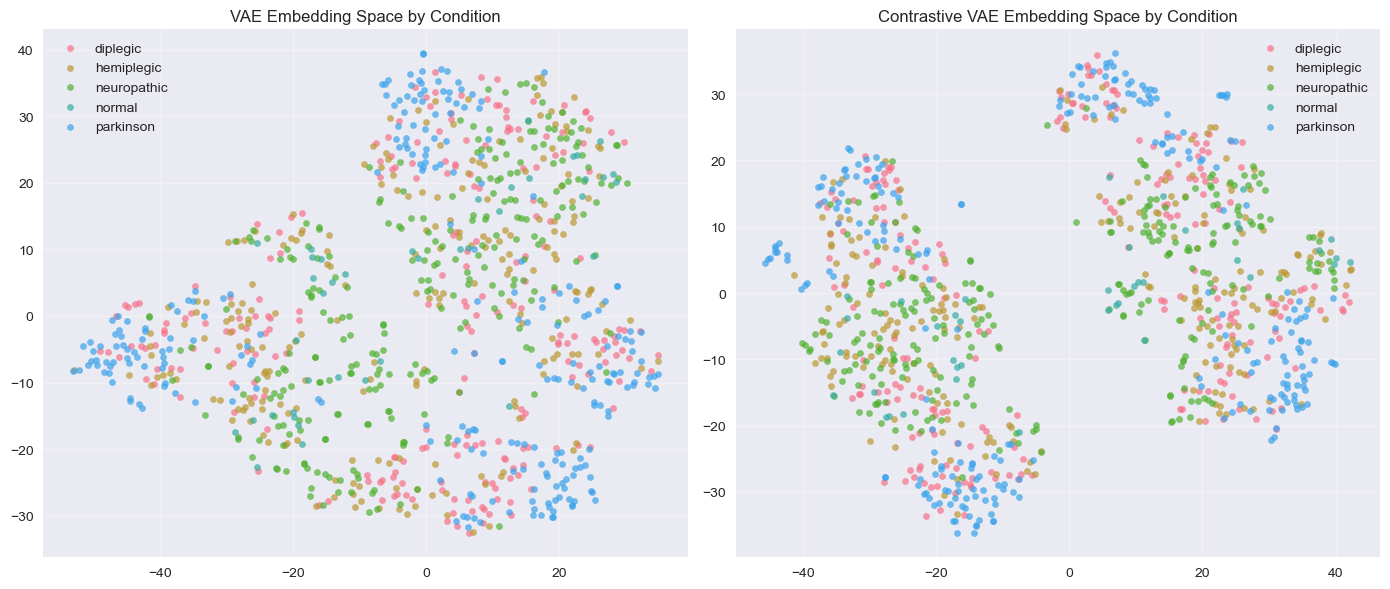

In [15]:
def tsne_2d(embeddings, n_components=2, n_pca=50, random_state=42):
    pca = PCA(n_components=min(n_pca, embeddings.shape[1]))
    emb_pca = pca.fit_transform(embeddings)
    tsne = TSNE(n_components=n_components, random_state=random_state, perplexity=min(30, len(embeddings)-1))
    return tsne.fit_transform(emb_pca)

print("Running t-SNE for VAE...")
emb_vae_2d = tsne_2d(embeddings_vae)

print("Running t-SNE for Contrastive VAE...")
emb_contrastive_2d = tsne_2d(embeddings_contrastive)

df_vae = pd.DataFrame({
    'x': emb_vae_2d[:,0],
    'y': emb_vae_2d[:,1],
    'condition': all_conditions
})
df_contrastive = pd.DataFrame({
    'x': emb_contrastive_2d[:,0],
    'y': emb_contrastive_2d[:,1],
    'condition': all_conditions
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cond in sorted(set(all_conditions)):
    m = df_vae['condition'] == cond
    axes[0].scatter(df_vae.loc[m,'x'], df_vae.loc[m,'y'], label=cond, alpha=0.7, s=20)
axes[0].set_title('VAE Embedding Space by Condition')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for cond in sorted(set(all_conditions)):
    m = df_contrastive['condition'] == cond
    axes[1].scatter(df_contrastive.loc[m,'x'], df_contrastive.loc[m,'y'], label=cond, alpha=0.7, s=20)
axes[1].set_title('Contrastive VAE Embedding Space by Condition')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

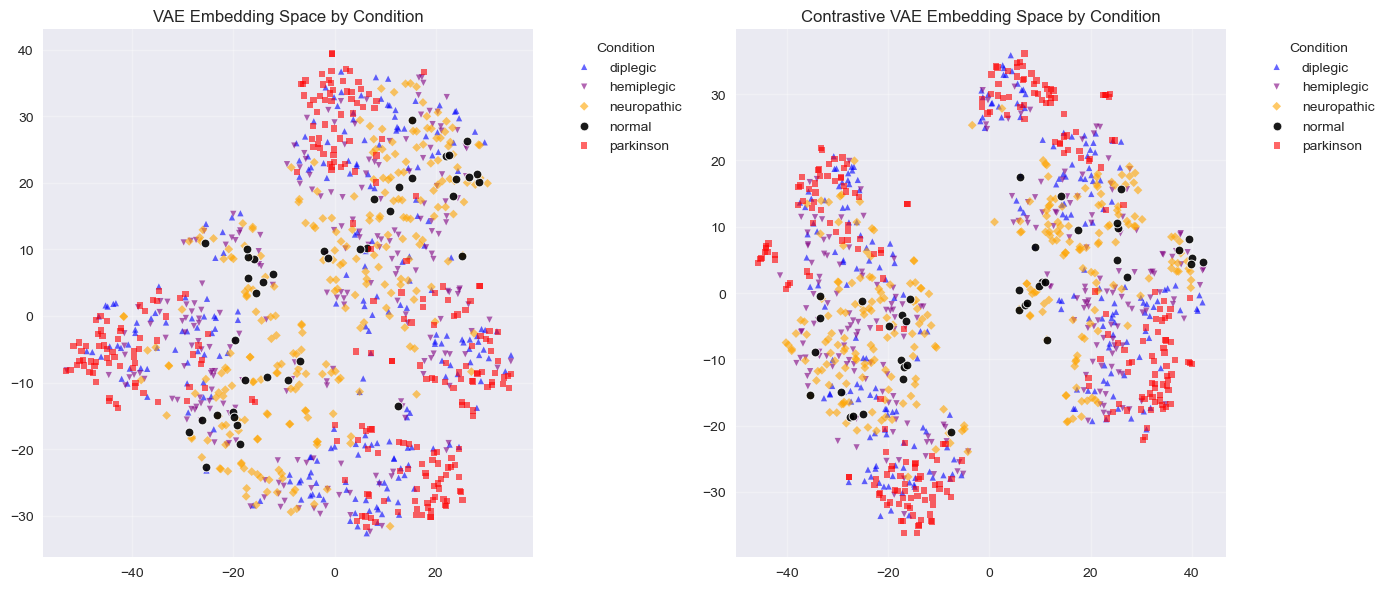

In [16]:
# Custom colors & markers – make 'normal' very distinct
unique_conditions = sorted(set(all_conditions))

color_map = {
    'normal': 'black',
    'parkinson': 'red',
    'neuropathic': 'orange',
    'diplegic': 'blue',
    'hemiplegic': 'purple',
}
marker_map = {
    'normal': 'o',        # circle
    'parkinson': 's',     # square
    'neuropathic': 'D',   # diamond
    'diplegic': '^',      # triangle
    'hemiplegic': 'v',    # triangle-down
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# VAE plot
for cond in unique_conditions:
    m = df_vae['condition'] == cond
    if m.sum() == 0:
        continue
    c = color_map.get(cond, 'gray')
    mk = marker_map.get(cond, 'o')
    size = 40 if cond == 'normal' else 20
    alpha = 0.9 if cond == 'normal' else 0.6
    edge = 'white' if cond == 'normal' else 'none'
    axes[0].scatter(
        df_vae.loc[m, 'x'], df_vae.loc[m, 'y'],
        label=cond,
        c=c,
        marker=mk,
        s=size,
        alpha=alpha,
        edgecolors=edge,
        linewidths=0.7 if cond == 'normal' else 0.0,
    )
axes[0].set_title('VAE Embedding Space by Condition')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

# Contrastive VAE plot
for cond in unique_conditions:
    m = df_contrastive['condition'] == cond
    if m.sum() == 0:
        continue
    c = color_map.get(cond, 'gray')
    mk = marker_map.get(cond, 'o')
    size = 40 if cond == 'normal' else 20
    alpha = 0.9 if cond == 'normal' else 0.6
    edge = 'white' if cond == 'normal' else 'none'
    axes[1].scatter(
        df_contrastive.loc[m, 'x'], df_contrastive.loc[m, 'y'],
        label=cond,
        c=c,
        marker=mk,
        s=size,
        alpha=alpha,
        edgecolors=edge,
        linewidths=0.7 if cond == 'normal' else 0.0,
    )
axes[1].set_title('Contrastive VAE Embedding Space by Condition')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [17]:
def make_balanced_binary(embeddings, is_pathological, random_seed=42):
    rng = np.random.default_rng(random_seed)
    is_pathological = np.array(is_pathological)
    idx_healthy = np.where(is_pathological == 0)[0]
    idx_path = np.where(is_pathological == 1)[0]

    n_healthy = len(idx_healthy)
    n_path = len(idx_path)
    target = min(n_healthy, n_path)

    idx_h_sel = rng.choice(idx_healthy, size=target, replace=False)
    idx_p_sel = rng.choice(idx_path, size=target, replace=False)

    idx_bal = np.concatenate([idx_h_sel, idx_p_sel])
    rng.shuffle(idx_bal)

    X_bal = embeddings[idx_bal]
    y_bal = is_pathological[idx_bal]

    print("Binary balanced counts:",
          "healthy:", (y_bal==0).sum(),
          "pathology:", (y_bal==1).sum())
    return X_bal, y_bal

In [18]:
# Binary labels: healthy (normal) vs any pathology
is_pathological = (all_conditions != 'normal').astype(int)

def eval_binary_classifier(embeddings, y_bin, name='model'):
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y_bin, test_size=0.2, random_state=42, stratify=y_bin
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=2000, class_weight='balanced')
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    print(f"\n{name} - Binary Healthy vs Pathology")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['healthy','pathological']))

print("== Binary Anomaly Detection ==")
eval_binary_classifier(embeddings_vae, is_pathological, name='VAE')
eval_binary_classifier(embeddings_contrastive, is_pathological, name='Contrastive VAE')

== Binary Anomaly Detection ==

VAE - Binary Healthy vs Pathology
Accuracy: 0.935
              precision    recall  f1-score   support

     healthy       0.27      0.38      0.32         8
pathological       0.97      0.96      0.97       192

    accuracy                           0.94       200
   macro avg       0.62      0.67      0.64       200
weighted avg       0.95      0.94      0.94       200


Contrastive VAE - Binary Healthy vs Pathology
Accuracy: 0.915
              precision    recall  f1-score   support

     healthy       0.20      0.38      0.26         8
pathological       0.97      0.94      0.95       192

    accuracy                           0.92       200
   macro avg       0.59      0.66      0.61       200
weighted avg       0.94      0.92      0.93       200



In [19]:
X_vae_bin, y_bin_vae = make_balanced_binary(embeddings_vae, is_pathological)
X_contr_bin, y_bin_contr = make_balanced_binary(embeddings_contrastive, is_pathological)

eval_binary_classifier(X_vae_bin, y_bin_vae, name='VAE (balanced)')
eval_binary_classifier(X_contr_bin, y_bin_contr, name='Contrastive (balanced)')

Binary balanced counts: healthy: 40 pathology: 40
Binary balanced counts: healthy: 40 pathology: 40

VAE (balanced) - Binary Healthy vs Pathology
Accuracy: 0.6875
              precision    recall  f1-score   support

     healthy       0.71      0.62      0.67         8
pathological       0.67      0.75      0.71         8

    accuracy                           0.69        16
   macro avg       0.69      0.69      0.69        16
weighted avg       0.69      0.69      0.69        16


Contrastive (balanced) - Binary Healthy vs Pathology
Accuracy: 0.875
              precision    recall  f1-score   support

     healthy       0.80      1.00      0.89         8
pathological       1.00      0.75      0.86         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16



In [20]:
# from imblearn.over_sampling import SMOTE

# def eval_binary_classifier_balanced(embeddings, y_bin, name='model'):
#     X_train, X_test, y_train, y_test = train_test_split(
#         embeddings, y_bin, test_size=0.2, random_state=42, stratify=y_bin
#     )
    
#     # Oversample minority class (healthy)
#     sm = SMOTE()
#     X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

#     scaler = StandardScaler()
#     X_train_s = scaler.fit_transform(X_train_res)
#     X_test_s = scaler.transform(X_test)

#     clf = LogisticRegression(max_iter=2000)
#     clf.fit(X_train_s, y_train_res)
#     y_pred = clf.predict(X_test_s)

#     print(f"\n{name} (SMOTE Oversampled) - Binary Healthy vs Pathology")
#     print("Accuracy:", accuracy_score(y_test, y_pred))
#     print(classification_report(y_test, y_pred, target_names=['healthy','pathological']))


In [21]:
import numpy as np
from collections import defaultdict

def make_balanced_by_condition(embeddings, conditions, max_per_class=None, random_seed=42):
    """
    Return balanced embeddings/conditions with (roughly) equal samples per condition.

    embeddings: np.array (N, D)
    conditions: np.array (N,) of strings: 'normal', 'parkinson', ...
    max_per_class: cap per class; if None, use min class size
    """
    rng = np.random.default_rng(random_seed)
    conditions = np.array(conditions)
    n = len(conditions)

    # group indices by condition
    idx_by_cond = defaultdict(list)
    for i, c in enumerate(conditions):
        idx_by_cond[c].append(i)

    # how many per class?
    class_counts = {c: len(idx) for c, idx in idx_by_cond.items()}
    print("Class counts before balancing:", class_counts)

    if max_per_class is None:
        target = min(class_counts.values())  # strict balance
    else:
        target = min(max_per_class, min(class_counts.values()))

    balanced_indices = []
    for c, idxs in idx_by_cond.items():
        if len(idxs) > target:
            chosen = rng.choice(idxs, size=target, replace=False)
        else:
            chosen = np.array(idxs)  # already <= target
        balanced_indices.append(chosen)

    balanced_indices = np.concatenate(balanced_indices)
    rng.shuffle(balanced_indices)

    emb_bal = embeddings[balanced_indices]
    cond_bal = conditions[balanced_indices]

    print("Balanced total samples:", len(cond_bal))
    print("Balanced class counts:", {c: (cond_bal == c).sum() for c in sorted(set(cond_bal))})
    return emb_bal, cond_bal

In [22]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

def oversample_minority(X, y):
    # Identify minority and majority classes
    minority_class = y == 0       # healthy
    majority_class = y == 1       # pathological

    X_min = X[minority_class]
    y_min = y[minority_class]

    X_maj = X[majority_class]
    y_maj = y[majority_class]

    # Randomly duplicate minority samples until sizes match
    n_to_add = len(X_maj) - len(X_min)
    idx = np.random.randint(0, len(X_min), size=n_to_add)

    X_res = np.vstack([X, X_min[idx]])
    y_res = np.hstack([y, y_min[idx]])

    return X_res, y_res


def eval_binary_classifier_manual_oversample(embeddings, y_bin, name='model'):
    # Split first
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y_bin, test_size=0.2, random_state=42, stratify=y_bin
    )

    # Manual oversampling
    X_train_res, y_train_res = oversample_minority(X_train, y_train)

    # Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_res)
    X_test_s = scaler.transform(X_test)

    # Train classifier
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_s, y_train_res)

    y_pred = clf.predict(X_test_s)

    print(f"\n{name} - Balanced by Manual Oversampling")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['healthy', 'pathological']))


In [23]:
embeddings_vae_bal, conditions_bal = make_balanced_by_condition(embeddings_vae, all_conditions)
embeddings_contr_bal, conditions_contr_bal = make_balanced_by_condition(embeddings_contrastive, all_conditions)

Class counts before balancing: {'parkinson': 249, 'diplegic': 228, 'hemiplegic': 223, 'neuropathic': 260, 'normal': 40}
Balanced total samples: 200
Balanced class counts: {'diplegic': 40, 'hemiplegic': 40, 'neuropathic': 40, 'normal': 40, 'parkinson': 40}
Class counts before balancing: {'parkinson': 249, 'diplegic': 228, 'hemiplegic': 223, 'neuropathic': 260, 'normal': 40}
Balanced total samples: 200
Balanced class counts: {'diplegic': 40, 'hemiplegic': 40, 'neuropathic': 40, 'normal': 40, 'parkinson': 40}


In [24]:
# def undersample_majority(X, y):
#     # Majority (pathological)
#     maj_idx = np.where(y == 1)[0]
#     min_idx = np.where(y == 0)[0]

#     # Randomly choose a subset equal to minority size
#     chosen_maj = np.random.choice(maj_idx, size=len(min_idx), replace=False)

#     # Combine indices
#     final_idx = np.hstack([min_idx, chosen_maj])

#     return X[final_idx], y[final_idx]


In [25]:
# X_train_bal, y_train_bal = undersample_majority(X_train, y_train)

# clf = LogisticRegression(
#     max_iter=2000,
#     class_weight='balanced'
# )
# clf.fit(X_train_bal, y_train_bal)


In [26]:
# Multi-class: normal, parkinson, neuropathy, etc.
le_cond = LabelEncoder()
y_cond = le_cond.fit_transform(all_conditions)
cond_names = le_cond.classes_
print("Condition classes:", cond_names)

def eval_multiclass_classifier(embeddings, y, name='model'):
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=3000, multi_class='multinomial')
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    print(f"\n{name} - Multi-class Condition Classification")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=cond_names))

print("== Multi-class Condition Classification ==")
eval_multiclass_classifier(embeddings_vae, y_cond, name='VAE')
eval_multiclass_classifier(embeddings_contrastive, y_cond, name='Contrastive VAE')

Condition classes: ['diplegic' 'hemiplegic' 'neuropathic' 'normal' 'parkinson']
== Multi-class Condition Classification ==

VAE - Multi-class Condition Classification
Accuracy: 0.49
              precision    recall  f1-score   support

    diplegic       0.39      0.41      0.40        46
  hemiplegic       0.38      0.41      0.39        44
 neuropathic       0.59      0.56      0.57        52
      normal       0.29      0.25      0.27         8
   parkinson       0.64      0.60      0.62        50

    accuracy                           0.49       200
   macro avg       0.46      0.45      0.45       200
weighted avg       0.50      0.49      0.49       200


Contrastive VAE - Multi-class Condition Classification
Accuracy: 0.52
              precision    recall  f1-score   support

    diplegic       0.42      0.43      0.43        46
  hemiplegic       0.35      0.34      0.34        44
 neuropathic       0.60      0.62      0.61        52
      normal       0.17      0.12      0.

In [27]:
# Subject Classification: Identify which subject (person) a sample belongs to
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def eval_subject_classifier(embeddings, subjects, name='model', min_samples_per_subject=5, test_size=0.2):
    """
    Train a classifier to identify which subject a sample belongs to.
    
    Parameters:
    - embeddings: np.array (N, D) of embeddings
    - subjects: np.array (N,) of subject IDs
    - name: model name for display
    - min_samples_per_subject: minimum samples required to include a subject
    - test_size: proportion of data for testing
    """
    subjects = np.array(subjects)
    
    # Filter subjects with too few samples
    from collections import Counter
    subject_counts = Counter(subjects)
    valid_subjects = [s for s, count in subject_counts.items() if count >= min_samples_per_subject]
    
    if len(valid_subjects) < 2:
        print(f"⚠️ {name}: Not enough subjects with {min_samples_per_subject}+ samples")
        return None
    
    # Filter data to valid subjects only
    valid_mask = np.isin(subjects, valid_subjects)
    embeddings_filtered = embeddings[valid_mask]
    subjects_filtered = subjects[valid_mask]
    
    print(f"\n{name} - Subject Classification")
    print(f"Valid subjects: {len(valid_subjects)}")
    print(f"Total samples: {len(subjects_filtered)}")
    print(f"Samples per subject: {dict(Counter(subjects_filtered))}")
    
    # Encode subject labels
    le_subj = LabelEncoder()
    y_subj = le_subj.fit_transform(subjects_filtered)
    subject_names = le_subj.classes_
    
    # Split data (stratified by subject)
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings_filtered, y_subj, 
        test_size=test_size, 
        random_state=42, 
        stratify=y_subj
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Train classifier
    clf = LogisticRegression(
        max_iter=3000, 
        multi_class='multinomial',
        class_weight='balanced'  # Handle imbalanced subjects
    )
    clf.fit(X_train_s, y_train)
    
    # Predictions
    y_pred = clf.predict(X_test_s)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.3f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=[f"Subject_{s}" for s in subject_names], zero_division=0))
    
    return {
        'classifier': clf,
        'scaler': scaler,
        'label_encoder': le_subj,
        'accuracy': accuracy,
        'n_subjects': len(valid_subjects),
        'y_test': y_test,
        'y_pred': y_pred
    }

print("== Subject Classification ==")
results_vae = eval_subject_classifier(embeddings_vae, all_subjects, name='VAE', min_samples_per_subject=5)
results_contrastive = eval_subject_classifier(embeddings_contrastive, all_subjects, name='Contrastive VAE', min_samples_per_subject=5)


== Subject Classification ==

VAE - Subject Classification
Valid subjects: 23
Total samples: 1000
Samples per subject: {'s11': 40, 's21': 35, 's12': 40, 's23': 48, 's19': 43, 's15': 57, 's22': 50, 's20': 60, 's16': 50, 's6': 46, 's13': 34, 's2': 53, 's14': 38, 's7': 31, 's8': 36, 's1': 36, 's10': 50, 's3': 41, 's5': 44, 's4': 38, 's9': 33, 's18': 52, 's17': 45}

Accuracy: 0.190

Classification Report:
              precision    recall  f1-score   support

  Subject_s1       0.00      0.00      0.00         7
 Subject_s10       0.30      0.30      0.30        10
 Subject_s11       0.33      0.38      0.35         8
 Subject_s12       0.29      0.25      0.27         8
 Subject_s13       0.25      0.14      0.18         7
 Subject_s14       0.40      0.25      0.31         8
 Subject_s15       0.20      0.18      0.19        11
 Subject_s16       0.20      0.30      0.24        10
 Subject_s17       0.15      0.22      0.18         9
 Subject_s18       0.09      0.10      0.10        10


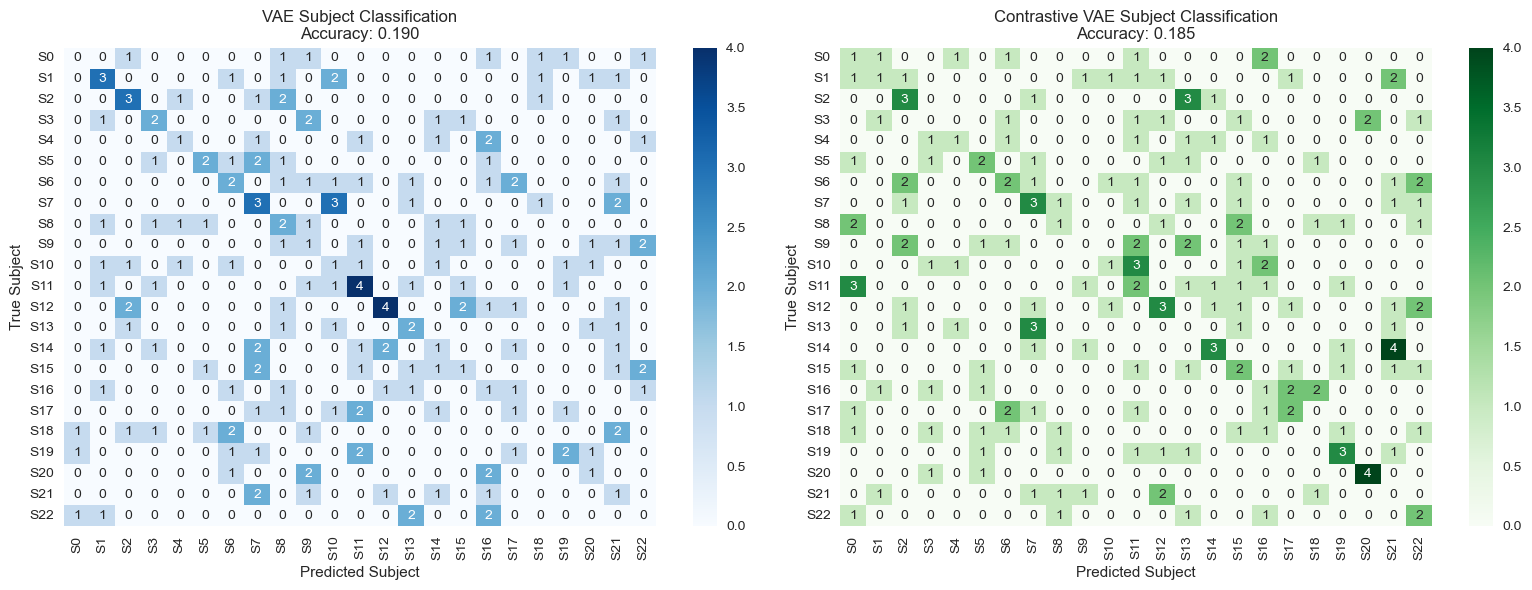


📊 Subject Classification Summary:
VAE Accuracy: 0.190 (23 subjects)
Contrastive VAE Accuracy: 0.185 (23 subjects)

Random baseline (1/23): 0.043


In [28]:
# Visualize Subject Classification Results
if results_vae is not None and results_contrastive is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Confusion matrix for VAE
    cm_vae = confusion_matrix(results_vae['y_test'], results_vae['y_pred'])
    sns.heatmap(cm_vae, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
                xticklabels=[f"S{i}" for i in range(len(cm_vae))],
                yticklabels=[f"S{i}" for i in range(len(cm_vae))])
    axes[0].set_title(f'VAE Subject Classification\nAccuracy: {results_vae["accuracy"]:.3f}')
    axes[0].set_xlabel('Predicted Subject')
    axes[0].set_ylabel('True Subject')
    
    # Confusion matrix for Contrastive VAE
    cm_contr = confusion_matrix(results_contrastive['y_test'], results_contrastive['y_pred'])
    sns.heatmap(cm_contr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=[f"S{i}" for i in range(len(cm_contr))],
                yticklabels=[f"S{i}" for i in range(len(cm_contr))])
    axes[1].set_title(f'Contrastive VAE Subject Classification\nAccuracy: {results_contrastive["accuracy"]:.3f}')
    axes[1].set_xlabel('Predicted Subject')
    axes[1].set_ylabel('True Subject')
    
    plt.tight_layout()
    plt.show()
    
    # Compare accuracies
    print(f"\n📊 Subject Classification Summary:")
    print(f"VAE Accuracy: {results_vae['accuracy']:.3f} ({results_vae['n_subjects']} subjects)")
    print(f"Contrastive VAE Accuracy: {results_contrastive['accuracy']:.3f} ({results_contrastive['n_subjects']} subjects)")
    print(f"\nRandom baseline (1/{results_vae['n_subjects']}): {1/results_vae['n_subjects']:.3f}")
else:
    print("⚠️ Subject classification results not available")


Running t-SNE for subject visualization...


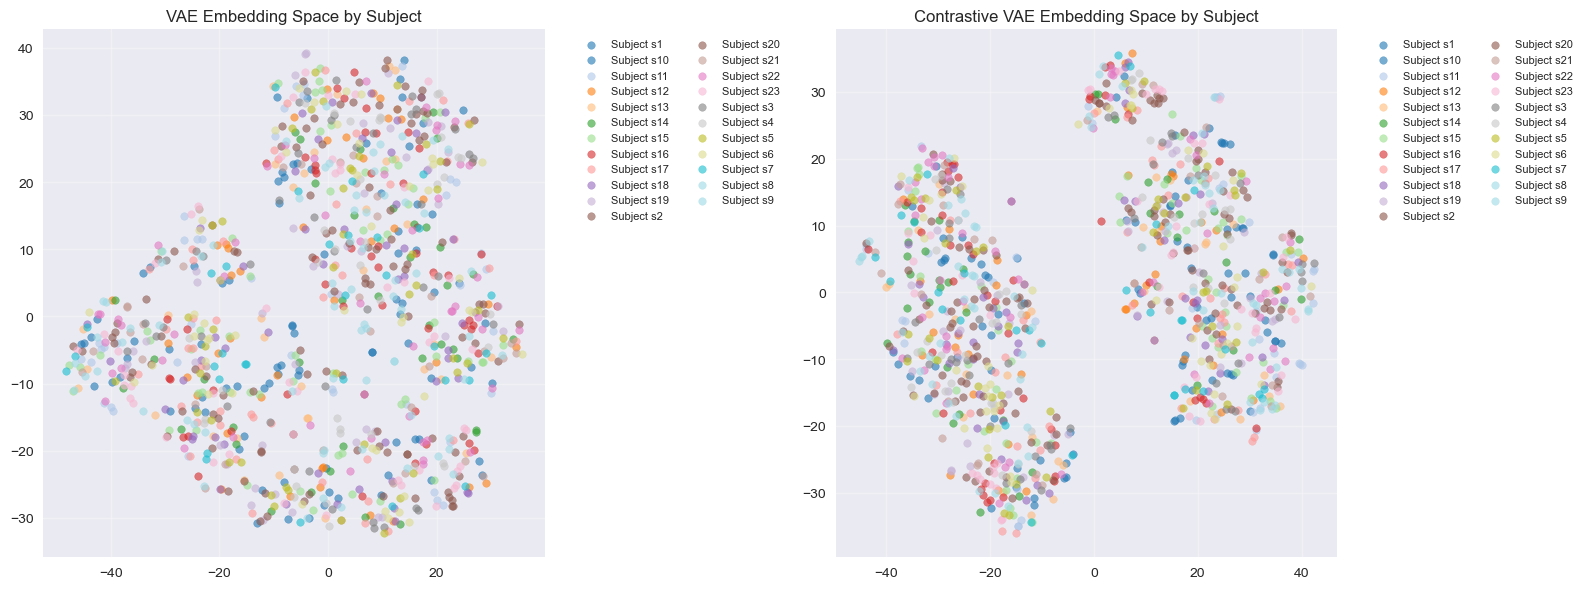

Visualized 23 subjects with 5+ samples each


In [29]:
# Visualize Subject Clusters in Embedding Space (t-SNE)
# Filter to subjects with enough samples for visualization
from collections import Counter
subject_counts = Counter(all_subjects)
valid_subjects_viz = [s for s, count in subject_counts.items() if count >= 5]

if len(valid_subjects_viz) > 1:
    valid_mask_viz = np.isin(all_subjects, valid_subjects_viz)
    emb_vae_viz = embeddings_vae[valid_mask_viz]
    emb_contr_viz = embeddings_contrastive[valid_mask_viz]
    subjects_viz = np.array(all_subjects)[valid_mask_viz]
    
    # Run t-SNE
    print("Running t-SNE for subject visualization...")
    emb_vae_2d_subj = tsne_2d(emb_vae_viz)
    emb_contr_2d_subj = tsne_2d(emb_contr_viz)
    
    # Create dataframes
    df_vae_subj = pd.DataFrame({
        'x': emb_vae_2d_subj[:, 0],
        'y': emb_vae_2d_subj[:, 1],
        'subject': subjects_viz
    })
    df_contr_subj = pd.DataFrame({
        'x': emb_contr_2d_subj[:, 0],
        'y': emb_contr_2d_subj[:, 1],
        'subject': subjects_viz
    })
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # VAE plot by subject
    unique_subjects = sorted(set(subjects_viz))
    colors_subj = plt.cm.tab20(np.linspace(0, 1, len(unique_subjects)))
    for i, subj in enumerate(unique_subjects):
        m = df_vae_subj['subject'] == subj
        axes[0].scatter(
            df_vae_subj.loc[m, 'x'], df_vae_subj.loc[m, 'y'],
            label=f'Subject {subj}',
            c=[colors_subj[i]],
            alpha=0.6,
            s=30
        )
    axes[0].set_title('VAE Embedding Space by Subject')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
    
    # Contrastive VAE plot by subject
    for i, subj in enumerate(unique_subjects):
        m = df_contr_subj['subject'] == subj
        axes[1].scatter(
            df_contr_subj.loc[m, 'x'], df_contr_subj.loc[m, 'y'],
            label=f'Subject {subj}',
            c=[colors_subj[i]],
            alpha=0.6,
            s=30
        )
    axes[1].set_title('Contrastive VAE Embedding Space by Subject')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Visualized {len(unique_subjects)} subjects with 5+ samples each")
else:
    print("⚠️ Not enough subjects with sufficient samples for visualization")


## Summary

- Compared healthy vs pathological gaits in VAE and Contrastive VAE embedding spaces.
- Visualized condition clusters with t-SNE.
- Evaluated:
  - Binary anomaly detection (healthy vs any pathology).
  - Multi-class classification (normal, Parkinson, neuropathy, etc.).
- Next steps:
  - Tune condition labels / folder mapping for Parkinson dataset.
  - Try projection-head embeddings (`use_projection=True`) for contrastive model.
  - Explore per-view or per-sequence effects if that metadata is available.

In [34]:
# Cross-View Nearest Neighbor Matching
# Collect samples with view information (front_1, front_2, back_1, back_2)

def collect_pathology_samples_by_view(root, gei_patterns=("*.png", "*.jpg")):
    """
    Collect pathological samples with view information extracted from folder structure.
    
    Expected structure:
      root/
        ConditionA/
          subject/
            silhouettes/
              side_view/
                [subject_id]pat[#]lvl[#]-[view_number]_[front|back]/
                  *.jpg or *.png
    
    Returns:
      samples dict with paths, subjects, conditions, views
    """
    import re
    samples = {
        "paths": [],
        "subjects": [],
        "conditions": [],
        "views": [],  # e.g., "front_1", "back_2"
    }
    root = Path(root)
    if not root.exists():
        print(f"⚠️ Pathology data not found at {root}")
        return samples

    # Pattern to match folder names like: s14pat1lvl1-1_back or s14pat1lvl1-2_front
    # Extract: view number (1 or 2) and direction (front or back)
    # Pattern: -(\d+)_(front|back) at the end of folder name
    view_pattern = re.compile(r'-(\d+)_(front|back)$', re.IGNORECASE)
    
    # Top-level dirs are conditions
    for cond_dir in sorted(d for d in root.iterdir() if d.is_dir()):
        condition_name = cond_dir.name.lower()

        # Second-level dirs are subjects
        subject_dirs = sorted(d for d in cond_dir.iterdir() if d.is_dir())
        if not subject_dirs:
            subject_dirs = [cond_dir]

        for subj_dir in subject_dirs:
            subject_id = subj_dir.name
            
            # Look for silhouettes/side_view folder structure
            silhouettes_dir = subj_dir / "silhouettes" / "side_view"
            if not silhouettes_dir.exists():
                # Try alternative: just silhouettes folder
                silhouettes_dir = subj_dir / "silhouettes"
                if not silhouettes_dir.exists():
                    # Try direct search in subject folder
                    search_dir = subj_dir
                else:
                    search_dir = silhouettes_dir
            else:
                search_dir = silhouettes_dir
            
            # Find all image files and extract view from parent folder name
            for img_path in search_dir.rglob("*.jpg"):
                # Also check for png
                if img_path.suffix.lower() not in ['.png', '.jpg']:
                    continue
                
                # Get the parent folder name (the view folder)
                parent_folder = img_path.parent.name
                
                # Try to extract view from parent folder name
                view_match = view_pattern.search(parent_folder.lower())
                
                if view_match:
                    view_number = view_match.group(1)  # e.g., "1" or "2"
                    direction = view_match.group(2).lower()  # e.g., "front" or "back"
                    view_type = f"{direction}_{view_number}"
                else:
                    # Try to extract from any parent folder in the path
                    view_type = "unknown"
                    for parent in img_path.parents:
                        parent_match = view_pattern.search(parent.name.lower())
                        if parent_match:
                            view_number = parent_match.group(1)
                            direction = parent_match.group(2).lower()
                            view_type = f"{direction}_{view_number}"
                            break
                
                # Only add if we found a valid view
                if view_type != "unknown":
                    samples["paths"].append(img_path)
                    samples["subjects"].append(subject_id)
                    samples["conditions"].append(condition_name)
                    samples["views"].append(view_type)
            
            # Also check for PNG files
            for img_path in search_dir.rglob("*.png"):
                if img_path.suffix.lower() not in ['.png', '.jpg']:
                    continue
                
                # Get the parent folder name (the view folder)
                parent_folder = img_path.parent.name
                
                # Try to extract view from parent folder name
                view_match = view_pattern.search(parent_folder.lower())
                
                if view_match:
                    view_number = view_match.group(1)  # e.g., "1" or "2"
                    direction = view_match.group(2).lower()  # e.g., "front" or "back"
                    view_type = f"{direction}_{view_number}"
                else:
                    # Try to extract from any parent folder in the path
                    view_type = "unknown"
                    for parent in img_path.parents:
                        parent_match = view_pattern.search(parent.name.lower())
                        if parent_match:
                            view_number = parent_match.group(1)
                            direction = parent_match.group(2).lower()
                            view_type = f"{direction}_{view_number}"
                            break
                
                # Only add if we found a valid view
                if view_type != "unknown":
                    samples["paths"].append(img_path)
                    samples["subjects"].append(subject_id)
                    samples["conditions"].append(condition_name)
                    samples["views"].append(view_type)

    print(f"🧍 Pathology by view: {len(samples['paths'])} images, {len(set(samples['subjects']))} subjects")
    print(f"   Conditions: {sorted(set(samples['conditions']))}")
    print(f"   Views: {sorted(set(samples['views']))}")
    print(f"   View distribution: {dict(Counter(samples['views']))}")
    return samples

from collections import Counter
pathology_samples_by_view = collect_pathology_samples_by_view(PATHOLOGY_ROOT)


🧍 Pathology by view: 429909 images, 23 subjects
   Conditions: ['diplegic', 'hemiplegic', 'neuropathic', 'normal', 'parkinson']
   Views: ['back_1', 'back_2', 'back_3', 'front_1', 'front_2', 'front_3']
   View distribution: {'back_1': 108735, 'front_1': 107697, 'back_2': 105774, 'front_2': 105149, 'back_3': 1297, 'front_3': 1257}


In [35]:
# Nearest Neighbor Cross-View Matching
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances

def cross_view_nearest_neighbor_matching(
    gallery_embeddings, gallery_subjects, gallery_views,
    query_embeddings, query_subjects, query_views,
    metric='euclidean',
    k=1,
    name='model'
):
    """
    Perform cross-view nearest neighbor matching.
    
    Parameters:
    - gallery_embeddings: np.array (N_gallery, D) - embeddings from one view (e.g., front_1)
    - gallery_subjects: np.array (N_gallery,) - subject IDs for gallery
    - gallery_views: np.array (N_gallery,) - view labels for gallery
    - query_embeddings: np.array (N_query, D) - embeddings from other views
    - query_subjects: np.array (N_query,) - subject IDs for queries
    - query_views: np.array (N_query,) - view labels for queries
    - metric: 'euclidean' or 'cosine'
    - k: number of nearest neighbors to consider
    - name: model name for display
    
    Returns:
    - results dict with accuracy, top-k accuracy, and detailed matches
    """
    gallery_subjects = np.array(gallery_subjects)
    query_subjects = np.array(query_subjects)
    
    print(f"\n{name} - Cross-View Nearest Neighbor Matching")
    print(f"Gallery: {len(gallery_embeddings)} samples from views: {sorted(set(gallery_views))}")
    print(f"Query: {len(query_embeddings)} samples from views: {sorted(set(query_views))}")
    
    # Build nearest neighbor index
    if metric == 'euclidean':
        nn = NearestNeighbors(n_neighbors=min(k, len(gallery_embeddings)), metric='euclidean')
    elif metric == 'cosine':
        nn = NearestNeighbors(n_neighbors=min(k, len(gallery_embeddings)), metric='cosine')
    else:
        raise ValueError(f"Unknown metric: {metric}")
    
    nn.fit(gallery_embeddings)
    
    # Find nearest neighbors for each query
    distances, indices = nn.kneighbors(query_embeddings)
    
    # Evaluate matches
    correct_matches = 0
    correct_matches_topk = 0
    match_details = []
    
    for i in range(len(query_embeddings)):
        query_subj = query_subjects[i]
        query_view = query_views[i]
        
        # Get k nearest neighbors
        nn_indices = indices[i]
        nn_subjects = gallery_subjects[nn_indices]
        nn_distances = distances[i]
        
        # Check if top-1 match is correct
        top1_correct = (nn_subjects[0] == query_subj)
        correct_matches += top1_correct
        
        # Check if any of top-k matches is correct
        topk_correct = (query_subj in nn_subjects)
        correct_matches_topk += topk_correct
        
        match_details.append({
            'query_idx': i,
            'query_subject': query_subj,
            'query_view': query_view,
            'nn_subjects': nn_subjects.tolist(),
            'nn_distances': nn_distances.tolist(),
            'top1_correct': top1_correct,
            'topk_correct': topk_correct
        })
    
    accuracy_top1 = correct_matches / len(query_embeddings)
    accuracy_topk = correct_matches_topk / len(query_embeddings)
    
    print(f"\nTop-1 Accuracy: {accuracy_top1:.3f} ({correct_matches}/{len(query_embeddings)})")
    print(f"Top-{k} Accuracy: {accuracy_topk:.3f} ({correct_matches_topk}/{len(query_embeddings)})")
    
    # Per-view breakdown
    print(f"\nPer-view accuracy (Top-1):")
    for view in sorted(set(query_views)):
        view_mask = np.array(query_views) == view
        view_correct = sum([match_details[i]['top1_correct'] 
                           for i in range(len(match_details)) if view_mask[i]])
        view_total = view_mask.sum()
        if view_total > 0:
            print(f"  {view}: {view_correct/view_total:.3f} ({view_correct}/{view_total})")
    
    return {
        'accuracy_top1': accuracy_top1,
        'accuracy_topk': accuracy_topk,
        'match_details': match_details,
        'gallery_size': len(gallery_embeddings),
        'query_size': len(query_embeddings),
        'k': k,
        'metric': metric
    }


In [37]:
# Perform Cross-View Matching: Use front_1 as gallery, other views as queries
# Only for normal subjects, limit to ~20 subjects
GALLERY_VIEW = 'front_1'
MAX_SUBJECTS = 30

# First filter: only normal condition
normal_mask = np.array(pathology_samples_by_view['conditions']) == 'normal'
normal_samples = {
    'paths': [pathology_samples_by_view['paths'][i] for i in range(len(pathology_samples_by_view['paths'])) if normal_mask[i]],
    'subjects': [pathology_samples_by_view['subjects'][i] for i in range(len(pathology_samples_by_view['subjects'])) if normal_mask[i]],
    'conditions': [pathology_samples_by_view['conditions'][i] for i in range(len(pathology_samples_by_view['conditions'])) if normal_mask[i]],
    'views': [pathology_samples_by_view['views'][i] for i in range(len(pathology_samples_by_view['views'])) if normal_mask[i]]
}

print(f"Normal samples: {len(normal_samples['paths'])} images from {len(set(normal_samples['subjects']))} subjects")

# Limit to ~20 subjects
unique_subjects = sorted(set(normal_samples['subjects']))[:MAX_SUBJECTS]
subject_mask = np.array([s in unique_subjects for s in normal_samples['subjects']])

filtered_samples = {
    'paths': [normal_samples['paths'][i] for i in range(len(normal_samples['paths'])) if subject_mask[i]],
    'subjects': [normal_samples['subjects'][i] for i in range(len(normal_samples['subjects'])) if subject_mask[i]],
    'conditions': [normal_samples['conditions'][i] for i in range(len(normal_samples['conditions'])) if subject_mask[i]],
    'views': [normal_samples['views'][i] for i in range(len(normal_samples['views'])) if subject_mask[i]]
}

print(f"Filtered to {len(unique_subjects)} subjects: {len(filtered_samples['paths'])} images")
print(f"Views available: {sorted(set(filtered_samples['views']))}")

# Filter samples by view: front_1 as gallery, other views as queries
gallery_mask = np.array(filtered_samples['views']) == GALLERY_VIEW
query_mask = np.array(filtered_samples['views']) != GALLERY_VIEW

gallery_paths = [filtered_samples['paths'][i] for i in range(len(filtered_samples['paths'])) if gallery_mask[i]]
gallery_subjects = np.array([filtered_samples['subjects'][i] for i in range(len(filtered_samples['subjects'])) if gallery_mask[i]])
gallery_views = np.array([filtered_samples['views'][i] for i in range(len(filtered_samples['views'])) if gallery_mask[i]])

query_paths = [filtered_samples['paths'][i] for i in range(len(filtered_samples['paths'])) if query_mask[i]]
query_subjects = np.array([filtered_samples['subjects'][i] for i in range(len(filtered_samples['subjects'])) if query_mask[i]])
query_views = np.array([filtered_samples['views'][i] for i in range(len(filtered_samples['views'])) if query_mask[i]])

print(f"\nGallery ({GALLERY_VIEW}): {len(gallery_paths)} samples from {len(set(gallery_subjects))} subjects")
print(f"Query (other views): {len(query_paths)} samples from {len(set(query_subjects))} subjects")
print(f"Query views: {sorted(set(query_views))}")

# Extract embeddings for gallery and query
print("\nExtracting gallery embeddings (VAE)...")
gallery_emb_vae = extract_embeddings_from_paths(vae, gallery_paths, model_type='vae')
print("Extracting query embeddings (VAE)...")
query_emb_vae = extract_embeddings_from_paths(vae, query_paths, model_type='vae')

print("\nExtracting gallery embeddings (Contrastive VAE)...")
gallery_emb_contr = extract_embeddings_from_paths(contrastive_vae, gallery_paths, model_type='contrastive')
print("Extracting query embeddings (Contrastive VAE)...")
query_emb_contr = extract_embeddings_from_paths(contrastive_vae, query_paths, model_type='contrastive')

print(f"\nShapes:")
print(f"Gallery VAE: {gallery_emb_vae.shape}, Query VAE: {query_emb_vae.shape}")
print(f"Gallery Contrastive: {gallery_emb_contr.shape}, Query Contrastive: {query_emb_contr.shape}")


Normal samples: 18782 images from 23 subjects
Filtered to 23 subjects: 18782 images
Views available: ['back_1', 'back_2', 'front_1', 'front_2']

Gallery (front_1): 4283 samples from 23 subjects
Query (other views): 14499 samples from 23 subjects
Query views: ['back_1', 'back_2', 'front_2']

Extracting gallery embeddings (VAE)...
Extracting query embeddings (VAE)...

Extracting gallery embeddings (Contrastive VAE)...
Extracting query embeddings (Contrastive VAE)...

Shapes:
Gallery VAE: (4283, 128), Query VAE: (14499, 128)
Gallery Contrastive: (4283, 128), Query Contrastive: (14499, 128)


In [38]:
# Run cross-view nearest neighbor matching
print("=" * 60)
print("CROSS-VIEW NEAREST NEIGHBOR MATCHING")
print("=" * 60)

# VAE matching
results_vae_nn = cross_view_nearest_neighbor_matching(
    gallery_emb_vae, gallery_subjects, gallery_views,
    query_emb_vae, query_subjects, query_views,
    metric='euclidean',
    k=5,  # Top-5 accuracy
    name='VAE'
)

print("\n" + "-" * 60)

# Contrastive VAE matching
results_contr_nn = cross_view_nearest_neighbor_matching(
    gallery_emb_contr, gallery_subjects, gallery_views,
    query_emb_contr, query_subjects, query_views,
    metric='euclidean',
    k=5,  # Top-5 accuracy
    name='Contrastive VAE'
)

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"VAE - Top-1: {results_vae_nn['accuracy_top1']:.3f}, Top-5: {results_vae_nn['accuracy_topk']:.3f}")
print(f"Contrastive VAE - Top-1: {results_contr_nn['accuracy_top1']:.3f}, Top-5: {results_contr_nn['accuracy_topk']:.3f}")


CROSS-VIEW NEAREST NEIGHBOR MATCHING

VAE - Cross-View Nearest Neighbor Matching
Gallery: 4283 samples from views: ['front_1']
Query: 14499 samples from views: ['back_1', 'back_2', 'front_2']

Top-1 Accuracy: 0.220 (3183/14499)
Top-5 Accuracy: 0.337 (4881/14499)

Per-view accuracy (Top-1):
  back_1: 0.039 (191/4918)
  back_2: 0.042 (212/5003)
  front_2: 0.607 (2780/4578)

------------------------------------------------------------

Contrastive VAE - Cross-View Nearest Neighbor Matching
Gallery: 4283 samples from views: ['front_1']
Query: 14499 samples from views: ['back_1', 'back_2', 'front_2']

Top-1 Accuracy: 0.254 (3682/14499)
Top-5 Accuracy: 0.366 (5306/14499)

Per-view accuracy (Top-1):
  back_1: 0.058 (287/4918)
  back_2: 0.070 (350/5003)
  front_2: 0.665 (3045/4578)

SUMMARY
VAE - Top-1: 0.220, Top-5: 0.337
Contrastive VAE - Top-1: 0.254, Top-5: 0.366


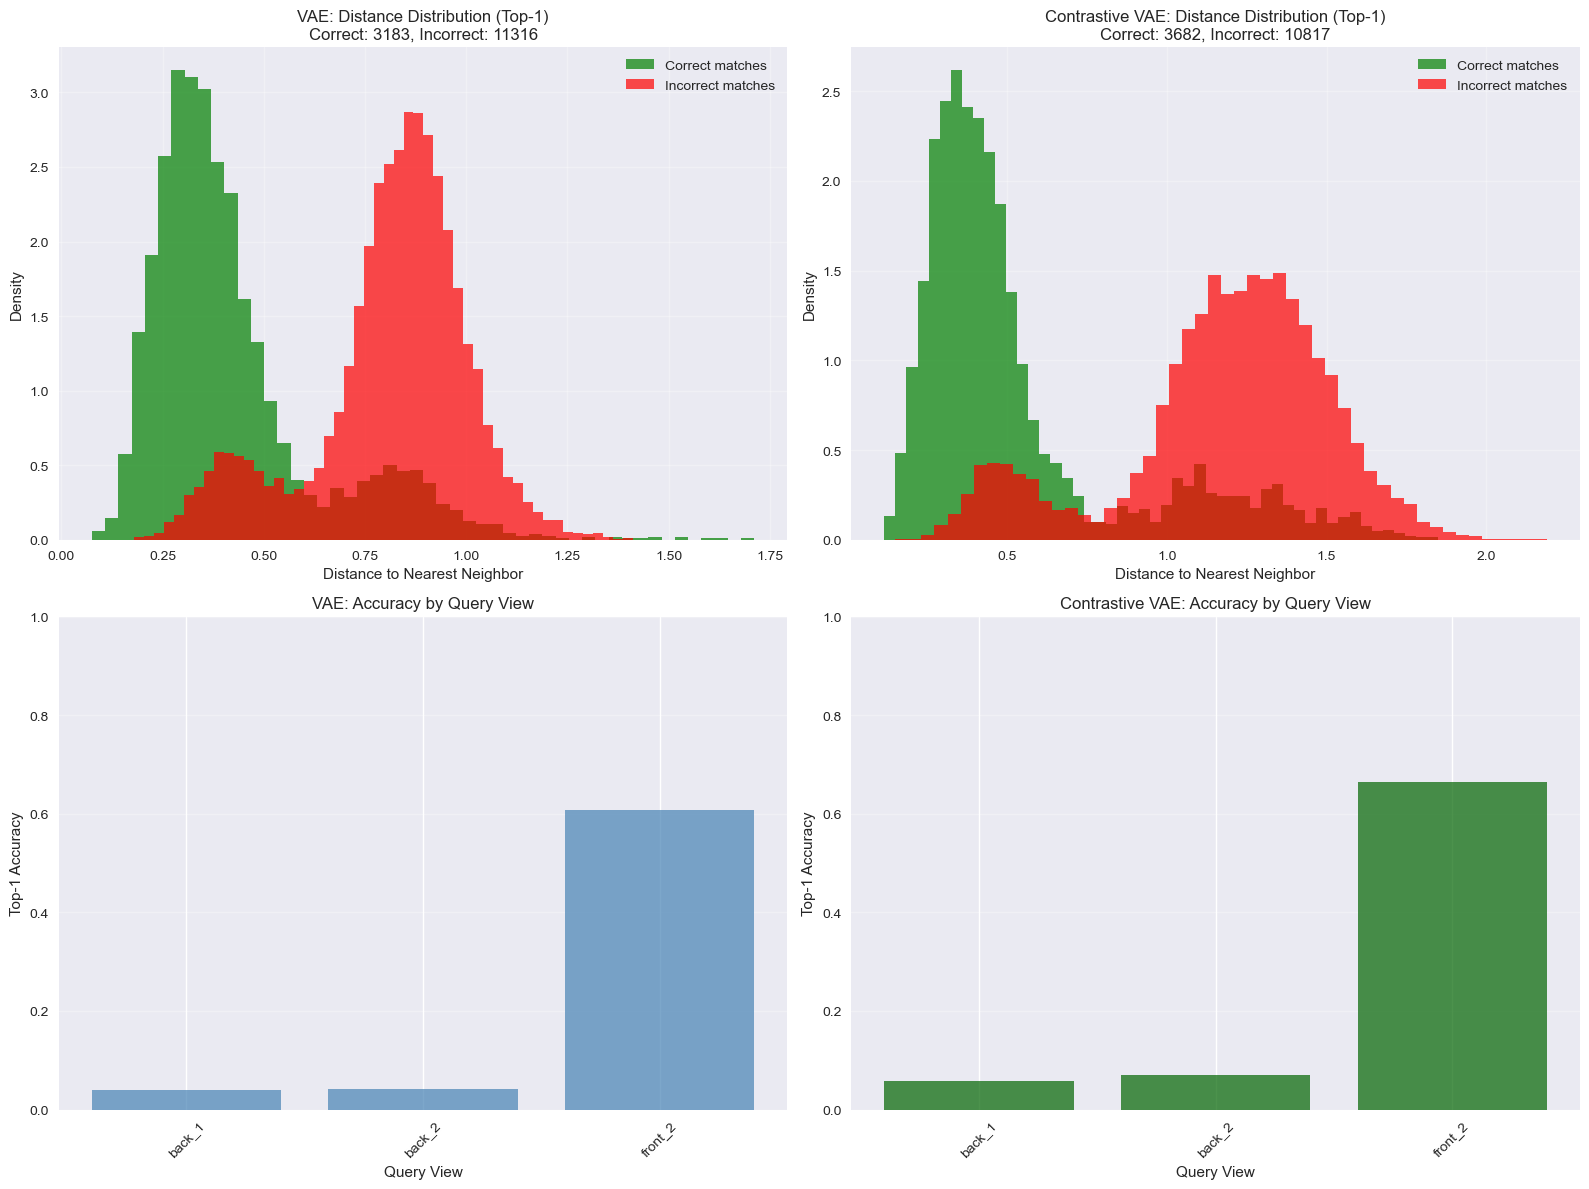


📊 Distance Statistics:

VAE - Correct matches:
  Mean distance: 0.423
  Median distance: 0.364

VAE - Incorrect matches:
  Mean distance: 0.813
  Median distance: 0.845

Contrastive VAE - Correct matches:
  Mean distance: 0.538
  Median distance: 0.418

Contrastive VAE - Incorrect matches:
  Mean distance: 1.183
  Median distance: 1.233


In [39]:
# Visualize Cross-View Matching Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distance distributions: correct vs incorrect matches (VAE)
vae_correct_distances = [r['nn_distances'][0] for r in results_vae_nn['match_details'] if r['top1_correct']]
vae_incorrect_distances = [r['nn_distances'][0] for r in results_vae_nn['match_details'] if not r['top1_correct']]

axes[0, 0].hist(vae_correct_distances, bins=50, alpha=0.7, label='Correct matches', color='green', density=True)
axes[0, 0].hist(vae_incorrect_distances, bins=50, alpha=0.7, label='Incorrect matches', color='red', density=True)
axes[0, 0].set_xlabel('Distance to Nearest Neighbor')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title(f'VAE: Distance Distribution (Top-1)\nCorrect: {len(vae_correct_distances)}, Incorrect: {len(vae_incorrect_distances)}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distance distributions: correct vs incorrect matches (Contrastive VAE)
contr_correct_distances = [r['nn_distances'][0] for r in results_contr_nn['match_details'] if r['top1_correct']]
contr_incorrect_distances = [r['nn_distances'][0] for r in results_contr_nn['match_details'] if not r['top1_correct']]

axes[0, 1].hist(contr_correct_distances, bins=50, alpha=0.7, label='Correct matches', color='green', density=True)
axes[0, 1].hist(contr_incorrect_distances, bins=50, alpha=0.7, label='Incorrect matches', color='red', density=True)
axes[0, 1].set_xlabel('Distance to Nearest Neighbor')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title(f'Contrastive VAE: Distance Distribution (Top-1)\nCorrect: {len(contr_correct_distances)}, Incorrect: {len(contr_incorrect_distances)}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Accuracy by query view (VAE)
view_accuracies_vae = {}
for view in sorted(set(query_views)):
    view_mask = np.array(query_views) == view
    view_correct = sum([results_vae_nn['match_details'][i]['top1_correct'] 
                       for i in range(len(results_vae_nn['match_details'])) if view_mask[i]])
    view_total = view_mask.sum()
    if view_total > 0:
        view_accuracies_vae[view] = view_correct / view_total

axes[1, 0].bar(view_accuracies_vae.keys(), view_accuracies_vae.values(), color='steelblue', alpha=0.7)
axes[1, 0].set_xlabel('Query View')
axes[1, 0].set_ylabel('Top-1 Accuracy')
axes[1, 0].set_title('VAE: Accuracy by Query View')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Accuracy by query view (Contrastive VAE)
view_accuracies_contr = {}
for view in sorted(set(query_views)):
    view_mask = np.array(query_views) == view
    view_correct = sum([results_contr_nn['match_details'][i]['top1_correct'] 
                       for i in range(len(results_contr_nn['match_details'])) if view_mask[i]])
    view_total = view_mask.sum()
    if view_total > 0:
        view_accuracies_contr[view] = view_correct / view_total

axes[1, 1].bar(view_accuracies_contr.keys(), view_accuracies_contr.values(), color='darkgreen', alpha=0.7)
axes[1, 1].set_xlabel('Query View')
axes[1, 1].set_ylabel('Top-1 Accuracy')
axes[1, 1].set_title('Contrastive VAE: Accuracy by Query View')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📊 Distance Statistics:")
print(f"\nVAE - Correct matches:")
print(f"  Mean distance: {np.mean(vae_correct_distances):.3f}")
print(f"  Median distance: {np.median(vae_correct_distances):.3f}")
print(f"\nVAE - Incorrect matches:")
print(f"  Mean distance: {np.mean(vae_incorrect_distances):.3f}")
print(f"  Median distance: {np.median(vae_incorrect_distances):.3f}")

print(f"\nContrastive VAE - Correct matches:")
print(f"  Mean distance: {np.mean(contr_correct_distances):.3f}")
print(f"  Median distance: {np.median(contr_correct_distances):.3f}")
print(f"\nContrastive VAE - Incorrect matches:")
print(f"  Mean distance: {np.mean(contr_incorrect_distances):.3f}")
print(f"  Median distance: {np.median(contr_incorrect_distances):.3f}")


In [ ]:
# Optional: Test with different gallery views or metrics
# Uncomment and modify to test different configurations

# # Test with different gallery view
# GALLERY_VIEW_TEST = 'back_1'
# gallery_mask_test = np.array(pathology_samples_by_view['views']) == GALLERY_VIEW_TEST
# query_mask_test = np.array(pathology_samples_by_view['views']) != GALLERY_VIEW_TEST
# 
# gallery_paths_test = [pathology_samples_by_view['paths'][i] for i in range(len(pathology_samples_by_view['paths'])) if gallery_mask_test[i]]
# gallery_subjects_test = np.array([pathology_samples_by_view['subjects'][i] for i in range(len(pathology_samples_by_view['subjects'])) if gallery_mask_test[i]])
# gallery_views_test = np.array([pathology_samples_by_view['views'][i] for i in range(len(pathology_samples_by_view['views'])) if gallery_mask_test[i]])
# 
# query_paths_test = [pathology_samples_by_view['paths'][i] for i in range(len(pathology_samples_by_view['paths'])) if query_mask_test[i]]
# query_subjects_test = np.array([pathology_samples_by_view['subjects'][i] for i in range(len(pathology_samples_by_view['subjects'])) if query_mask_test[i]])
# query_views_test = np.array([pathology_samples_by_view['views'][i] for i in range(len(pathology_samples_by_view['views'])) if query_mask_test[i]])
# 
# # Extract embeddings
# gallery_emb_test = extract_embeddings_from_paths(contrastive_vae, gallery_paths_test, model_type='contrastive')
# query_emb_test = extract_embeddings_from_paths(contrastive_vae, query_paths_test, model_type='contrastive')
# 
# # Test with cosine distance
# results_test = cross_view_nearest_neighbor_matching(
#     gallery_emb_test, gallery_subjects_test, gallery_views_test,
#     query_emb_test, query_subjects_test, query_views_test,
#     metric='cosine',  # Try cosine instead of euclidean
#     k=5,
#     name=f'Contrastive VAE (Gallery: {GALLERY_VIEW_TEST}, Cosine)'
# )

print("💡 Tip: You can modify GALLERY_VIEW in cell 26 to test different gallery views")
print("💡 Tip: You can change metric='euclidean' to metric='cosine' in cell 27 to test cosine distance")


💡 Tip: You can modify GALLERY_VIEW in cell 26 to test different gallery views
💡 Tip: You can change metric='euclidean' to metric='cosine' in cell 27 to test cosine distance
